# Kagome bands from the `extkag_0_*_shb.csv` simulations

Extract and plot the three lowest-frequency Kagome bands as functions of mesh complexity and face-union setting. The highest-frequency retained band is also analyzed as the flat band.

In [1]:
import csv
import re
from collections import defaultdict
from pathlib import Path

from IPython.display import Markdown, display
from matplotlib.patches import Patch
import matplotlib.pyplot as plt
import numpy as np

## Discover the simulation files

Expected filenames follow `extkag_0_<mesh>[_<face-union-setting>]_shb.csv`. The existing `extkag_0_shb.csv` file is interpreted as the normal mesh with the default face-union setting. For compatibility with the source notebook, the filename suffix `cm` is displayed as the `CF` setting.

In [2]:
# The first path is correct when the notebook runs from its own directory;
# the second also permits execution from the repository root.
data_dir = next(
    path.resolve()
    for path in (Path('../../../data/simulation'), Path('data/simulation'))
    if path.is_dir()
)

filename_pattern = re.compile(
    r'^extkag_0(?:_(?P<variant>.*))?_shb\.csv$'
)
band_files = {}

for csv_path in data_dir.glob('extkag_0*_shb.csv'):
    match = filename_pattern.match(csv_path.name)
    if match is None:
        continue

    label = match.group('variant') or ''
    if label in band_files:
        raise ValueError(f'Multiple files found for {label!r}')
    band_files[label] = csv_path

band_files = dict(sorted(band_files.items()))
if not band_files:
    raise FileNotFoundError(
        f'No extkag_0_*_shb.csv files found in {data_dir}'
    )

print(f'Found {len(band_files)} band-structure files:')
for label, csv_path in band_files.items():
    print(f'  {label or "normal/default"}: {csv_path.name}')

Found 10 band-structure files:
  normal/default: extkag_0_shb.csv
  extrafine: extkag_0_extrafine_shb.csv
  extrafine_cf: extkag_0_extrafine_cf_shb.csv
  extremelyfine: extkag_0_extremelyfine_shb.csv
  extremelyfine_cf: extkag_0_extremelyfine_cf_shb.csv
  fine: extkag_0_fine_shb.csv
  fine_cf: extkag_0_fine_cf_shb.csv
  finer: extkag_0_finer_shb.csv
  finer_cf: extkag_0_finer_cf_shb.csv
  normal_cf: extkag_0_normal_cf_shb.csv


## Choose simulation files to omit

In [3]:
# Add exact CSV filenames to this set to exclude them from all analysis.
OMIT_FILES = set()

available_files = {csv_path.name for csv_path in band_files.values()}
unknown_omit_files = OMIT_FILES - available_files
if unknown_omit_files:
    raise ValueError(
        'Files selected for omission were not found: '
        + ', '.join(sorted(unknown_omit_files))
    )

band_files = {
    label: csv_path
    for label, csv_path in band_files.items()
    if csv_path.name not in OMIT_FILES
}
if not band_files:
    raise ValueError('All discovered simulation files were omitted')

if OMIT_FILES:
    print('Omitting: ' + ', '.join(sorted(OMIT_FILES)))
else:
    print('No simulation files omitted.')

No simulation files omitted.


## Extract and organize the three lowest eigenfrequency bands

In [4]:
BAND_COUNT = 3

UNIT_TO_HZ = {
    'hz': 1.0,
    'khz': 1.0e3,
    'mhz': 1.0e6,
    'ghz': 1.0e9,
}


def frequency_scale_to_hz(column_name):
    normalized = column_name.casefold().replace(' ', '')
    for unit, scale in UNIT_TO_HZ.items():
        if f'({unit})' in normalized:
            return scale
    raise ValueError(f'Could not identify the unit in {column_name!r}')


def real_part(value):
    return complex(value.strip().replace('i', 'j')).real


def extract_eigenfrequencies(csv_path, band_count=BAND_COUNT):
    b_index = None
    eigenfrequency_index = None
    scale_to_hz = None
    frequencies_by_b = defaultdict(list)

    with Path(csv_path).open(newline='', encoding='utf-8-sig') as csv_file:
        for row in csv.reader(csv_file):
            if not row:
                continue

            if row[0].lstrip().startswith('%'):
                header = [cell.strip().lstrip('% ') for cell in row]
                frequency_columns = [
                    index for index, name in enumerate(header)
                    if name.casefold().startswith('eigenfrequency')
                ]
                if frequency_columns:
                    eigenfrequency_index = frequency_columns[-1]
                    scale_to_hz = frequency_scale_to_hz(
                        header[eigenfrequency_index]
                    )
                    b_columns = [
                        index for index, name in enumerate(header)
                        if name.casefold() == 'b'
                    ]
                    if not b_columns:
                        raise ValueError(f'No b column found in {csv_path}')
                    b_index = b_columns[0]
                continue

            if b_index is None or eigenfrequency_index is None:
                raise ValueError(
                    f'No Eigenfrequency column found in {csv_path}'
                )

            b_value = float(row[b_index])
            frequency_hz = (
                real_part(row[eigenfrequency_index]) * scale_to_hz
            )
            frequencies_by_b[b_value].append(frequency_hz)

    if not frequencies_by_b:
        raise ValueError(f'No eigenfrequencies found in {csv_path}')

    insufficient_b_values = [
        b_value for b_value, frequencies in frequencies_by_b.items()
        if len(frequencies) < band_count
    ]
    if insufficient_b_values:
        raise ValueError(
            f'{csv_path} has fewer than {band_count} bands at '
            f'{len(insufficient_b_values)} b values'
        )

    b_values = np.asarray(sorted(frequencies_by_b))
    bands_hz = np.stack([
        np.sort(frequencies_by_b[b_value])[:band_count]
        for b_value in b_values
    ])

    return {
        'b': b_values,
        'bands_hz': bands_hz,
    }


band_data = {
    label: extract_eigenfrequencies(csv_path)
    for label, csv_path in band_files.items()
}

for label, dataset in band_data.items():
    b_count, band_count = dataset['bands_hz'].shape
    print(
        f'{label or "normal/default"}: selected the {band_count} lowest '
        f'bands at {b_count} b values'
    )

normal/default: selected the 3 lowest bands at 48 b values
extrafine: selected the 3 lowest bands at 48 b values
extrafine_cf: selected the 3 lowest bands at 48 b values
extremelyfine: selected the 3 lowest bands at 48 b values
extremelyfine_cf: selected the 3 lowest bands at 48 b values
fine: selected the 3 lowest bands at 48 b values
fine_cf: selected the 3 lowest bands at 48 b values
finer: selected the 3 lowest bands at 48 b values
finer_cf: selected the 3 lowest bands at 48 b values
normal_cf: selected the 3 lowest bands at 48 b values


## Organize mesh and face-union variants

In [5]:
MESH_ORDER = (
    'coarse',
    'normal',
    'fine',
    'finer',
    'extrafine',
    'extremelyfine',
)
MESH_ORDER_INDEX = {
    mesh_complexity: index
    for index, mesh_complexity in enumerate(MESH_ORDER)
}
MESH_DISPLAY_NAMES = {
    'extrafine': 'extra fine',
    'extremelyfine': 'extremely fine',
}
FACE_UNION_DISPLAY_NAMES = {
    'default': 'non-CF',
    'cf': 'CF',
}


def mesh_display_name(mesh_complexity):
    return MESH_DISPLAY_NAMES.get(
        mesh_complexity, mesh_complexity.replace('_', ' ')
    )


def face_union_display_name(face_union_setting):
    return FACE_UNION_DISPLAY_NAMES.get(
        face_union_setting, face_union_setting.replace('_', ' ')
    )


def simulation_variant(label):
    variant_name = label.strip('_') or 'normal'
    for mesh_complexity in sorted(MESH_ORDER, key=len, reverse=True):
        if variant_name == mesh_complexity:
            return mesh_complexity, 'default'
        prefix = f'{mesh_complexity}_'
        if variant_name.startswith(prefix):
            setting = variant_name.removeprefix(prefix)
            # Match the extkag_1 source notebook's cm -> CF convention.
            if setting == 'cm':
                setting = 'cf'
            return mesh_complexity, setting

    # A setting-only filename such as extkag_0_face_union_shb.csv
    # is treated as a normal-mesh simulation.
    return 'normal', variant_name


variant_by_label = {
    label: simulation_variant(label) for label in band_data
}
labels_by_variant = defaultdict(list)
for label, variant in variant_by_label.items():
    labels_by_variant[variant].append(label)
duplicate_variants = {
    variant: labels for variant, labels in labels_by_variant.items()
    if len(labels) > 1
}
if duplicate_variants:
    raise ValueError(
        'Multiple files map to the same mesh/face-union variant; '
        f'use OMIT_FILES to select one: {duplicate_variants}'
    )


def variant_sort_key(label):
    mesh_complexity, face_union_setting = variant_by_label[label]
    face_union_order = {'default': 0, 'cf': 1}
    return (
        MESH_ORDER_INDEX.get(mesh_complexity, len(MESH_ORDER)),
        mesh_complexity,
        face_union_order.get(face_union_setting, 2),
        face_union_setting,
    )


ordered_labels = sorted(band_data, key=variant_sort_key)
mesh_complexities = list(dict.fromkeys(
    variant_by_label[label][0] for label in ordered_labels
))
face_union_settings = list(dict.fromkeys(
    variant_by_label[label][1] for label in ordered_labels
))

mesh_colormap = plt.colormaps['viridis']
mesh_color_values = np.linspace(0.08, 0.92, len(mesh_complexities))
mesh_colors = {
    mesh_complexity: mesh_colormap(color_value)
    for mesh_complexity, color_value in zip(
        mesh_complexities, mesh_color_values
    )
}
line_styles = ('-', '--', ':', '-.')
face_union_line_styles = {
    setting: line_styles[index % len(line_styles)]
    for index, setting in enumerate(face_union_settings)
}

## Plot all three Kagome bands

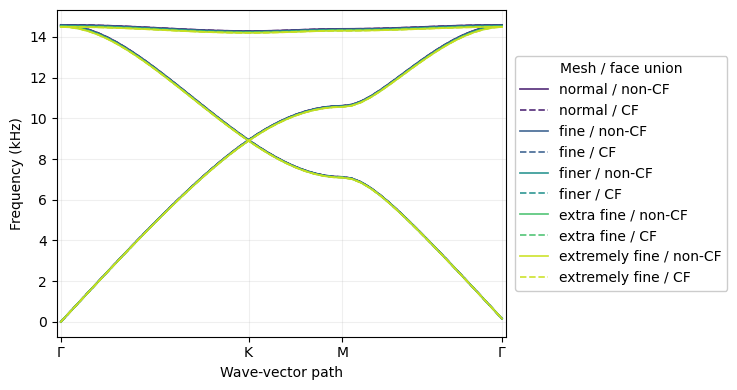

In [6]:
fig, ax = plt.subplots(figsize=(7.5, 4.0), tight_layout=True)
for label in ordered_labels:
    dataset = band_data[label]
    mesh_complexity, face_union_setting = variant_by_label[label]
    display_label = (
        f'{mesh_display_name(mesh_complexity)} / '
        f'{face_union_display_name(face_union_setting)}'
    )
    for band_index, band_hz in enumerate(dataset['bands_hz'].T):
        ax.plot(
            dataset['b'], band_hz / 1e3,
            color=mesh_colors[mesh_complexity],
            linestyle=face_union_line_styles[face_union_setting],
            linewidth=1.25, alpha=0.9,
            label=display_label if band_index == 0 else None,
        )

b_max = max(dataset['b'][-1] for dataset in band_data.values())
ax.set_xlim(-0.02, b_max + 0.02)
ax.set_xticks([0, 1, 1.5, b_max], ['Γ', 'K', 'M', 'Γ'])
ax.set_xlabel('Wave-vector path')
ax.set_ylabel('Frequency (kHz)')
ax.grid(alpha=0.2)
ax.legend(
    title='Mesh / face union', loc='center left',
    bbox_to_anchor=(1.02, 0.5), borderaxespad=0.0,
    frameon=True, facecolor='white', framealpha=1.0,
    edgecolor='0.8',
)
plt.show()

## Plot and measure the flat bands

At every path coordinate, the flat band is the highest-frequency band among the three retained Kagome bands. The reported flat-band frequency is its mean across all sampled path coordinates; its bandwidth is $f_\mathrm{max}-f_\mathrm{min}$.

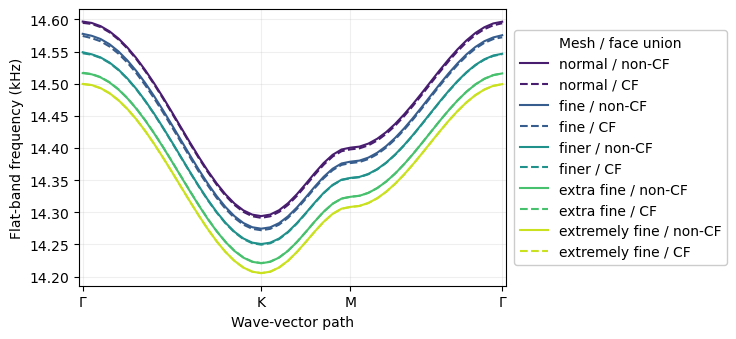

| Mesh complexity | Face-union setting | Mean frequency (kHz) | Minimum frequency (kHz) | Maximum frequency (kHz) | Bandwidth (Hz) | Quality factor |
|:--|:--|--:|--:|--:|--:|--:|
| normal | non-CF | 14.447922479 | 14.294025177 | 14.596655401 | 302.630223265 | 47.741175098 |
| normal | CF | 14.445560959 | 14.291328082 | 14.594667873 | 303.339791149 | 47.621714594 |
| fine | non-CF | 14.427172315 | 14.274467337 | 14.577580456 | 303.113119022 | 47.596660815 |
| fine | CF | 14.424483081 | 14.272056442 | 14.574287319 | 302.230877925 | 47.726702117 |
| finer | non-CF | 14.400966438 | 14.250589968 | 14.548925680 | 298.335711618 | 48.271011070 |
| finer | CF | 14.400307375 | 14.249569791 | 14.547349876 | 297.780085774 | 48.358866368 |
| extra fine | non-CF | 14.370860613 | 14.220684069 | 14.516427307 | 295.743238598 | 48.592355589 |
| extra fine | CF | 14.371074771 | 14.220952309 | 14.517056016 | 296.103706399 | 48.533923962 |
| extremely fine | non-CF | 14.354874704 | 14.205311987 | 14.499561335 | 294.249348360 | 48.784728951 |
| extremely fine | CF | 14.354733503 | 14.205289863 | 14.499574728 | 294.284865068 | 48.778361401 |

In [7]:
flat_band_metrics = {}

fig, ax = plt.subplots(figsize=(7.5, 3.5), tight_layout=True)
for label in ordered_labels:
    dataset = band_data[label]
    flat_band_hz = dataset['bands_hz'][:, -1]
    flat_band_metrics[label] = {
        'mean_hz': flat_band_hz.mean(),
        'minimum_hz': flat_band_hz.min(),
        'maximum_hz': flat_band_hz.max(),
        'bandwidth_hz': np.ptp(flat_band_hz),
        'quality_factor': flat_band_hz.mean() / np.ptp(flat_band_hz)
    }
    mesh_complexity, face_union_setting = variant_by_label[label]
    display_label = (
        f'{mesh_display_name(mesh_complexity)} / '
        f'{face_union_display_name(face_union_setting)}'
    )
    ax.plot(
        dataset['b'], flat_band_hz / 1e3,
        color=mesh_colors[mesh_complexity],
        linestyle=face_union_line_styles[face_union_setting],
        linewidth=1.5, label=display_label,
    )

ax.set_xlim(-0.02, b_max + 0.02)
ax.set_xticks([0, 1, 1.5, b_max], ['Γ', 'K', 'M', 'Γ'])
ax.set_xlabel('Wave-vector path')
ax.set_ylabel('Flat-band frequency (kHz)')
ax.grid(alpha=0.2)
legend = ax.legend(
    title='Mesh / face union', loc='center left',
    bbox_to_anchor=(1.02, 0.5), borderaxespad=0.0,
    frameon=True, facecolor='white', framealpha=1.0,
    edgecolor='0.8',
)
legend.set_zorder(10)
plt.show()

flat_band_metrics_table = [
    '| Mesh complexity | Face-union setting | Mean frequency (kHz) | Minimum frequency (kHz) | Maximum frequency (kHz) | Bandwidth (Hz) | Quality factor |',
    '|:--|:--|--:|--:|--:|--:|--:|',
]
for label in ordered_labels:
    metrics = flat_band_metrics[label]
    mesh_complexity, face_union_setting = variant_by_label[label]
    flat_band_metrics_table.append(
        f'| {mesh_display_name(mesh_complexity)} '
        f'| {face_union_display_name(face_union_setting)} '
        f'| {metrics["mean_hz"] / 1e3:.9f} '
        f'| {metrics["minimum_hz"] / 1e3:.9f} '
        f'| {metrics["maximum_hz"] / 1e3:.9f} '
        f'| {metrics["bandwidth_hz"]:.9f} '
        f'| {metrics["quality_factor"]:.9f} |'
    )

display(Markdown('\n'.join(flat_band_metrics_table)))

## Compare bandwidths by mesh and face-union setting

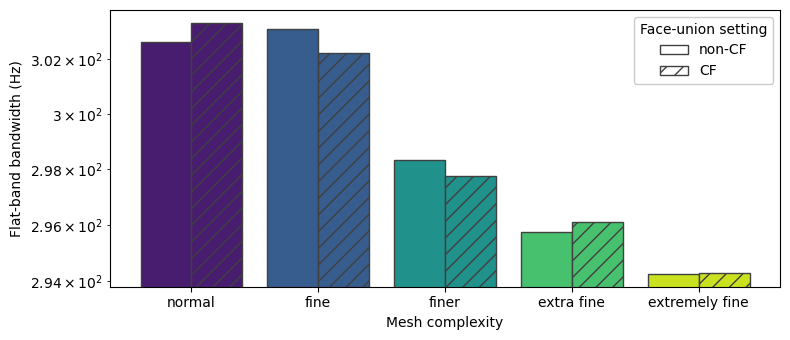

In [8]:
bandwidths_by_variant = {
    variant_by_label[label]: metrics['bandwidth_hz']
    for label, metrics in flat_band_metrics.items()
}
bar_positions = np.arange(len(mesh_complexities))
bar_width = 0.8 / len(face_union_settings)
hatches = ('', '//', '\\', '..', 'xx')

fig, ax = plt.subplots(figsize=(8, 3.5), tight_layout=True)
for setting_index, face_union_setting in enumerate(face_union_settings):
    offset = (
        setting_index - (len(face_union_settings) - 1) / 2
    ) * bar_width
    values = [
        bandwidths_by_variant.get(
            (mesh_complexity, face_union_setting), np.nan
        )
        for mesh_complexity in mesh_complexities
    ]
    ax.bar(
        bar_positions + offset, values, width=bar_width,
        color=[mesh_colors[mesh] for mesh in mesh_complexities],
        edgecolor='0.25',
        hatch=hatches[setting_index % len(hatches)],
        label=face_union_display_name(face_union_setting),
    )

ax.set_xticks(
    bar_positions,
    [mesh_display_name(mesh) for mesh in mesh_complexities],
)
ax.set_xlabel('Mesh complexity')
ax.set_ylabel('Flat-band bandwidth (Hz)')
ax.grid(axis='y', alpha=0.2)
legend_handles = [
    Patch(
        facecolor='white', edgecolor='0.25',
        hatch=hatches[index % len(hatches)],
        label=face_union_display_name(setting),
    )
    for index, setting in enumerate(face_union_settings)
]
ax.legend(
    handles=legend_handles, title='Face-union setting',
    frameon=True, facecolor='white', framealpha=1.0,
    edgecolor='0.8',
)
positive_bandwidths = [
    value for value in bandwidths_by_variant.values() if value > 0
]
if (
    positive_bandwidths
    and len(positive_bandwidths) == len(bandwidths_by_variant)
):
    ax.set_yscale('log')
plt.show()

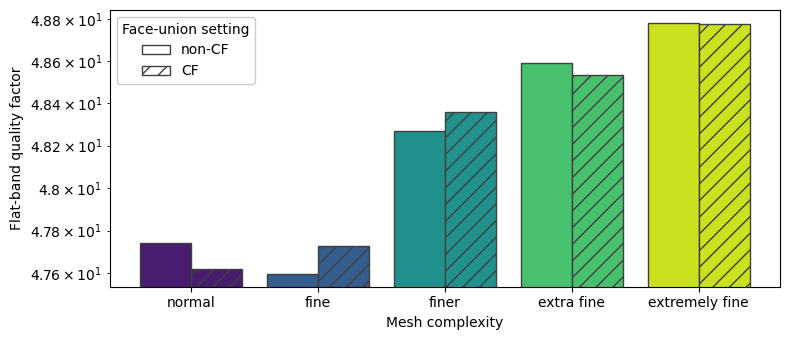

In [10]:
quality_factors_by_variant = {
    variant_by_label[label]: metrics['quality_factor']
    for label, metrics in flat_band_metrics.items()
}
bar_positions = np.arange(len(mesh_complexities))
bar_width = 0.8 / len(face_union_settings)
hatches = ('', '//', '\\', '..', 'xx')

fig, ax = plt.subplots(figsize=(8, 3.5), tight_layout=True)
for setting_index, face_union_setting in enumerate(face_union_settings):
    offset = (
        setting_index - (len(face_union_settings) - 1) / 2
    ) * bar_width
    values = [
        quality_factors_by_variant.get(
            (mesh_complexity, face_union_setting), np.nan
        )
        for mesh_complexity in mesh_complexities
    ]
    ax.bar(
        bar_positions + offset, values, width=bar_width,
        color=[mesh_colors[mesh] for mesh in mesh_complexities],
        edgecolor='0.25',
        hatch=hatches[setting_index % len(hatches)],
        label=face_union_display_name(face_union_setting),
    )

ax.set_xticks(
    bar_positions,
    [mesh_display_name(mesh) for mesh in mesh_complexities],
)
ax.set_xlabel('Mesh complexity')
ax.set_ylabel('Flat-band quality factor')
ax.grid(axis='y', alpha=0.2)
legend_handles = [
    Patch(
        facecolor='white', edgecolor='0.25',
        hatch=hatches[index % len(hatches)],
        label=face_union_display_name(setting),
    )
    for index, setting in enumerate(face_union_settings)
]
ax.legend(
    handles=legend_handles, title='Face-union setting',
    frameon=True, facecolor='white', framealpha=1.0,
    edgecolor='0.8',
)
positive_quality_factors = [
    value for value in quality_factors_by_variant.values() if value > 0
]
if (
    positive_quality_factors
    and len(positive_quality_factors) == len(quality_factors_by_variant)
):
    ax.set_yscale('log')
plt.show()